In [1]:
import sys
import logging
import random

import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Importing necessary modules for data loading and transformation
from data_loader import DASDataLoader, fft

logging.basicConfig(level=logging.INFO)

In [2]:
decim_dict = {
    # The 'regular' label will be decimated by a factor of 50
    'regular': 50,
}

# Initializing the DASDataLoader with dataset parameters
parser = DASDataLoader(
    '/nobackup/carda/datasets/DAS-dataset/data',  # Path to the dataset directory
    2048,  # Sample length
    transform=fft,  # Applying FFT as a preprocessing step
    fsize=8192,  # Window size for sliding window segmentation
    # Step size for the sliding window (overlap of 75% with fsize=8192)
    shift=2048,
    # Dictionary specifying the decimation factor for each label
    decimate=decim_dict,
)

# Parsing the dataset into features (x) and labels (y)
x, y = parser.parse_dataset()

# Output parsed dataset details
print(x, y)
print(f'The dataset contains {len(x)} elements')

INFO:data_loader:Parsing dataset for label [walk]...
INFO:data_loader:Parsing dataset for label [regular]...
INFO:data_loader:Parsing dataset for label [fence]...
INFO:data_loader:Parsing dataset for label [running]...
INFO:data_loader:Parsing dataset for label [car]...
INFO:data_loader:Parsing dataset for label [openclose]...
INFO:data_loader:Parsing dataset for label [manipulation]...
INFO:data_loader:Parsing dataset for label [longboard]...
INFO:data_loader:Parsing dataset for label [construction]...
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/walk/walking_2023-04-17T121933+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/regular/regularshit_2023-04-17T130103+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/fence/plot_2023-11-07T150119Z.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/running/running_2023-04-17T122413+0100.h5
INFO:data_loader:Processing

[[6.007571  6.004615  5.6936083 ... 4.6331477 4.520332  4.7448416]
 [6.1014843 5.8538203 5.66252   ... 4.394238  4.67528   4.2667637]
 [6.3045597 5.886345  5.4256725 ... 4.285132  4.6436286 4.3120937]
 ...
 [5.435545  5.280978  4.861414  ... 4.586738  4.277773  3.914524 ]
 [5.2884583 5.432711  5.0745287 ... 4.245294  4.5102262 4.1668377]
 [5.8312097 5.4262433 5.4621015 ... 4.467898  4.2403216 3.8805227]] [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
The dataset contains 118643 elements


In [3]:
x.shape

(118643, 2048)

In [4]:
y.argmax(axis=1)
Y = y.argmax(axis=1)
Y.shape

(118643,)

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


In [6]:
def get_device():
    """Detect and return best available device (MPS > CUDA > CPU)"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon (MPS)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

In [7]:
class SimilarityDataset(Dataset):
    def __init__(self, x, y, pairs_per_sample=2, seed=42):
        self.x = torch.FloatTensor(x)
        self.y = torch.LongTensor(y)
        self.pairs_per_sample = pairs_per_sample
        self.seed = seed
        self.rng = np.random.RandomState(seed)
        self.class_indices = {c: np.where(self.y == c)[0] for c in np.unique(self.y)}
        
    def __len__(self):
        return len(self.x) * self.pairs_per_sample
    
    def __getitem__(self, idx):
        anchor_idx = idx % len(self.x)
        anchor_sample = self.x[anchor_idx]
        anchor_label = self.y[anchor_idx].item()

        if self.rng.rand() < 0.5:
            positive_idx = self.rng.choice(self.class_indices[anchor_label])
            pair = self.x[positive_idx]
            similarity_label = 1.0
        else:
            # Randomly select a different class
            negative_classes = [c for c in self.class_indices.keys()
                               if c != anchor_label]
            negative_class = self.rng.choice(negative_classes)
            positive_idx = self.rng.choice(self.class_indices[negative_class])
            pair = self.x[positive_idx]
            similarity_label = 0.0
    
        return anchor_sample, pair, torch.FloatTensor([similarity_label])

In [8]:
dataset = SimilarityDataset(x, Y)
dataset[0]

(tensor([6.0076, 6.0046, 5.6936,  ..., 4.6331, 4.5203, 4.7448]),
 tensor([5.9859, 5.8263, 5.6123,  ..., 3.9816, 4.4009, 4.0801]),
 tensor([1.]))

In [9]:
class EmbeddingNetwork(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super(EmbeddingNetwork, self).__init__()
        self.embedding_dim = embedding_dim
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
        )
    
    def forward(self, x):
        return self.network(x)
    

In [10]:
class EmbeddingConvNetwork(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super(EmbeddingConvNetwork, self).__init__()
        self.embedding_dim = embedding_dim
        self.network = nn.Sequential(
            nn.Conv1d(input_dim, 131_072, groups=input_dim, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Conv1d(32_768, 131_072, groups=32_768, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Flatten(),
            nn.Linear(32_768, embedding_dim),
        )
    
    def forward(self, x):
        return self.network(x)

embedding_conv_net = EmbeddingConvNetwork(input_dim=2048, embedding_dim=128)

print(embedding_conv_net)


EmbeddingConvNetwork(
  (network): Sequential(
    (0): Conv1d(2048, 131072, kernel_size=(3,), stride=(1,), padding=(1,), groups=2048)
    (1): LeakyReLU(negative_slope=0.01)
    (2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32768, 131072, kernel_size=(3,), stride=(1,), padding=(1,), groups=32768)
    (4): LeakyReLU(negative_slope=0.01)
    (5): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=32768, out_features=128, bias=True)
  )
)


In [11]:
class SimilarityHead(nn.Module):
    def __init__(self, embedding_network):
        super(SimilarityHead, self).__init__()

        # Learnable weights for different similarity measures
        self.similarity_weights = nn.Parameter(torch.ones(embedding_network.embedding_dim + 3) / 4)  # Equal initial weights

        # Learnable transformation for each similarity measure
        self.l1_transform = nn.Linear(1, 1)
        self.l2_transform = nn.Linear(1, 1)
        self.element_wise_transform = nn.Linear(embedding_network.embedding_dim, 1)
        self.cosine_transform = nn.Linear(1, 1)

        # Final combination layer
        self.combination_layer = nn.Linear(embedding_network.embedding_dim + 3, 1)

    def forward(self, embedding_1, embedding_2):
        l1_distance = torch.sum(torch.abs(embedding_1 - embedding_2), dim=1, keepdim=True)

        l2_distance = F.pairwise_distance(embedding_1, embedding_2, keepdim=True)

        element_wise_product = embedding_1 * embedding_2

        cosine_similarity = F.cosine_similarity(embedding_1, embedding_2, dim=1).unsqueeze(1)

        combined_features = torch.cat([l1_distance, l2_distance, element_wise_product, cosine_similarity], dim=1)
        
        weighted_features = combined_features * F.softmax(self.similarity_weights, dim=0)
        
        # Final similarity score
        similarity = torch.sigmoid(self.combination_layer(weighted_features))
        
        return similarity

In [12]:
class SiameseClassifier:
    def __init__(self, input_dim=2048, embedding_dim=128):
        self.device = get_device()
        self.embedding_network = EmbeddingNetwork(input_dim, embedding_dim).to(self.device)
        self.similarity_head = SimilarityHead(self.embedding_network).to(self.device)

        self.training_history = {
            'epochs': [],
            'train_loss': [],
            'train_acc': [],
            'val_acc': []
        }
    
    def forward(self, x1, x2):
        embedding_1 = self.embedding_network(x1)
        embedding_2 = self.embedding_network(x2)
        return self.similarity_head(embedding_1, embedding_2)

    def fit(
        self, 
        train_loader, 
        val_loader=None, 
        epochs=20, 
        lr=1e-3, 
        weight_decay=1e-4, 
        log_interval=50
    ):
        import torch
        import torch.nn as nn
        import torch.optim as optim

        self.embedding_network.train()
        self.similarity_head.train()

        criterion = nn.BCELoss()
        optimizer = optim.Adam(
            list(self.embedding_network.parameters()) + list(self.similarity_head.parameters()),
            lr=lr, 
            weight_decay=weight_decay
        )

        for epoch in range(1, epochs + 1):
            train_loss = 0.0
            correct = 0
            total = 0

            for batch_idx, (x1, x2, labels) in enumerate(train_loader):
                x1 = x1.to(self.device)
                x2 = x2.to(self.device)
                labels = labels.float().to(self.device).view(-1, 1)

                optimizer.zero_grad()
                outputs = self.forward(x1, x2)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * x1.size(0)
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                if log_interval and (batch_idx + 1) % log_interval == 0:
                    print(f"Epoch [{epoch}/{epochs}] Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

            avg_loss = train_loss / total if total > 0 else 0
            train_acc = correct / total if total > 0 else 0

            self.training_history['epochs'].append(epoch)
            self.training_history['train_loss'].append(avg_loss)
            self.training_history['train_acc'].append(train_acc)

            val_acc = None
            if val_loader is not None:
                val_acc = self.evaluate(val_loader)
                self.training_history['val_acc'].append(val_acc)

            print(f"Epoch {epoch}: Train Loss={avg_loss:.4f} | Train Acc={train_acc:.4f}" +
                  (f" | Val Acc={val_acc:.4f}" if val_acc is not None else ''))

    def evaluate(self, data_loader):
        import torch
        self.embedding_network.eval()
        self.similarity_head.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x1, x2, labels in data_loader:
                x1 = x1.to(self.device)
                x2 = x2.to(self.device)
                labels = labels.float().to(self.device).view(-1, 1)
                outputs = self.forward(x1, x2)
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        acc = correct / total if total > 0 else 0
        self.embedding_network.train()
        self.similarity_head.train()
        return acc
        

In [13]:
set_seed(42)


In [14]:
# Split dataset into train and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    x, Y, 
    test_size=0.2, 
    random_state=42, 
    stratify=Y
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

# Create SimilarityDataset instances for training and validation
train_dataset = SimilarityDataset(X_train, Y_train, pairs_per_sample=2, seed=42)
val_dataset = SimilarityDataset(X_val, Y_val, pairs_per_sample=2, seed=42)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Get input dimension from the data
input_dim = x.shape[1]
print(f"Input dimension: {input_dim}")

# Initialize the Siamese Classifier
model = SiameseClassifier(input_dim=input_dim, embedding_dim=1024)

# Train the model
model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4,
    log_interval=50
)

print("\nTraining completed!")


Training samples: 94914
Validation samples: 23729
Input dimension: 2048
Using CUDA: NVIDIA GeForce GTX 1650 SUPER
Epoch [1/20] Batch [50/2967] Loss: 0.6664
Epoch [1/20] Batch [100/2967] Loss: 0.6471
Epoch [1/20] Batch [150/2967] Loss: 0.6454
Epoch [1/20] Batch [200/2967] Loss: 0.6676
Epoch [1/20] Batch [250/2967] Loss: 0.6141
Epoch [1/20] Batch [300/2967] Loss: 0.6284
Epoch [1/20] Batch [350/2967] Loss: 0.6664
Epoch [1/20] Batch [400/2967] Loss: 0.6523
Epoch [1/20] Batch [450/2967] Loss: 0.6201
Epoch [1/20] Batch [500/2967] Loss: 0.6221
Epoch [1/20] Batch [550/2967] Loss: 0.5983
Epoch [1/20] Batch [600/2967] Loss: 0.5842
Epoch [1/20] Batch [650/2967] Loss: 0.6391
Epoch [1/20] Batch [700/2967] Loss: 0.6504
Epoch [1/20] Batch [750/2967] Loss: 0.6484
Epoch [1/20] Batch [800/2967] Loss: 0.6363
Epoch [1/20] Batch [850/2967] Loss: 0.5913
Epoch [1/20] Batch [900/2967] Loss: 0.6628
Epoch [1/20] Batch [950/2967] Loss: 0.6254
Epoch [1/20] Batch [1000/2967] Loss: 0.5491
Epoch [1/20] Batch [1050/2

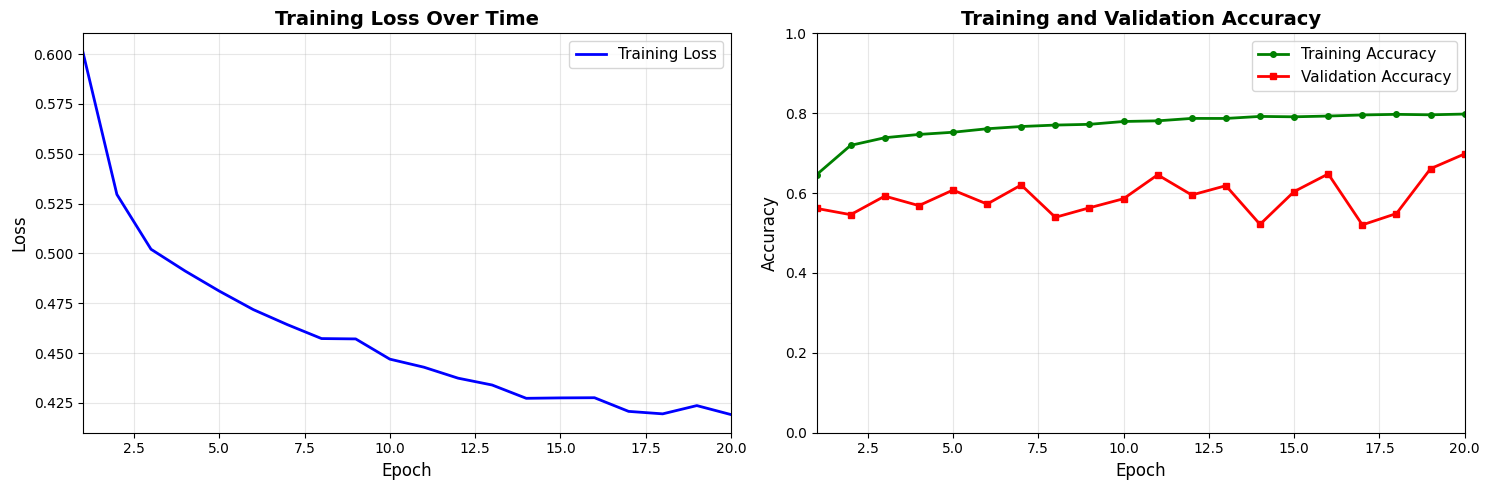


Training Summary
Total Epochs: 20
Final Training Loss: 0.4192
Final Training Accuracy: 0.7979
Final Validation Accuracy: 0.6982
Best Validation Accuracy: 0.6982 (Epoch 20)


In [15]:
import matplotlib.pyplot as plt

# Extract training history
epochs = model.training_history['epochs']
train_loss = model.training_history['train_loss']
train_acc = model.training_history['train_acc']
val_acc = model.training_history['val_acc']

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training Loss
axes[0].plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_xlim([min(epochs), max(epochs)])

# Plot 2: Training and Validation Accuracy
axes[1].plot(epochs, train_acc, 'g-', linewidth=2, label='Training Accuracy', marker='o', markersize=4)
if val_acc:
    axes[1].plot(epochs, val_acc, 'r-', linewidth=2, label='Validation Accuracy', marker='s', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].set_xlim([min(epochs), max(epochs)])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total Epochs: {len(epochs)}")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
if val_acc:
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"Best Validation Accuracy: {max(val_acc):.4f} (Epoch {epochs[val_acc.index(max(val_acc))]})")
print("="*50)
